# 1. Data Pipeline
BOLD -> FFT -> Hilbert pipeline

In [1]:
from pathlib import Path
import sys
import torch

import matplotlib.pyplot as plt
import numpy as np
#import scienceplots
import matplotlib.patches as patches
#plt.style.use('science')

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import load_mat_data, fft_bandpass_3d, hilbert_transform
from src.models import CoupledHopfModel
from src.metrics import compute_static_fc, phase_coherence_matrix

def _to_numpy(x: torch.Tensor | np.ndarray) -> np.ndarray:
    if isinstance(x, np.ndarray):
        return x
    return x.detach().cpu().numpy()

plt.rcParams["figure.dpi"] = 140
%matplotlib inline

In [2]:
# Auto-create parent dirs for savefig (added for reproducible runs)
import matplotlib.figure as _mpl_figure
from pathlib import Path as _Path
_orig_savefig = _mpl_figure.Figure.savefig
def _patched_savefig(self, fname, *args, **kwargs):
    if isinstance(fname, (str, _Path)):
        p = _Path(fname)
        if p.parent and not p.parent.exists():
            p.parent.mkdir(parents=True, exist_ok=True)
    return _orig_savefig(self, fname, *args, **kwargs)
_mpl_figure.Figure.savefig = _patched_savefig


In [3]:
dataset_path = project_root / "data" / "ts_young" / "ts_young_TR0.72.mat"
subject_index = 0
roi_indices = [0, 49, 99]
focus_roi = 25
dt = 0.72
f_lo, f_hi = 0.008, 0.08
w, h = 2.5, 1.5
v_lim = 2.5
max_timepoints = 200

data = load_mat_data(str(dataset_path))
raw_timeseries = data["timeseries_all"].transpose(2, 0, 1)


print(f"dataset: {dataset_path}")
print(f"subjects x rois x timepoints: {raw_timeseries.shape}")


dataset: /home/dani/projects/neuroscience_control/data/ts_young/ts_young_TR0.72.mat
subjects x rois x timepoints: (94, 100, 1200)


In [4]:
ts = torch.as_tensor(raw_timeseries)
time = np.arange(max_timepoints, dtype=np.float32) * dt

subject_ts = ts[subject_index : subject_index + 1]
mean = subject_ts.mean(dim=2, keepdim=True)
std = subject_ts.std(dim=2, keepdim=True) + 1e-8
normalized = (subject_ts - mean) / std

filtered = fft_bandpass_3d(normalized, dt=dt, f_lo=f_lo, f_hi=f_hi)
analytic = hilbert_transform(filtered)

real = _to_numpy(normalized[0, :, :max_timepoints])
filtered = _to_numpy(filtered[0, :, :max_timepoints])
analytic = _to_numpy(analytic[0,: , :max_timepoints])
normalized = _to_numpy(normalized[0, :, :max_timepoints])

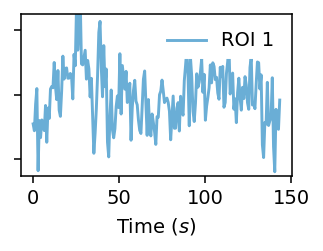

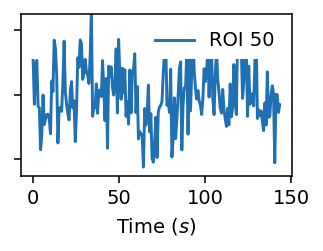

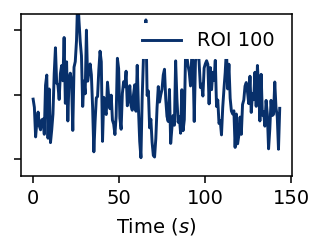

In [5]:
# Colormap for ROIs

cmap = plt.cm.Blues
colors = cmap(np.linspace(0.5, 1, len(roi_indices)))

(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
for i, roi in enumerate(roi_indices):
    fig, ax = plt.subplots(figsize=(w, h))
    fig.patch.set_alpha(0.0)
    # ax.patch.set_alpha(0.8)
    plt.plot(time, normalized[roi], label=f"ROI {roi+1}", alpha=1.0, color=colors[i])
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); #ax.set_yticks([-1, 0, 1]);
    ax.set_ylim(-v_lim,v_lim)
    #ax.set_xticks([]); ax.set_xticklabels([])
    plt.legend(loc="upper right", framealpha=1, facecolor="white", frameon=True, edgecolor="white")
    ax.set_xlabel("Time ($s$)")
    plt.savefig(project_root / "paper_new" / "images" / "representation" / f"raw_timeseries_roi{roi}.svg", dpi=100, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"raw_timeseries_roi{roi}.png", dpi=200, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"raw_timeseries_roi{roi}.svg", bbox_inches="tight")

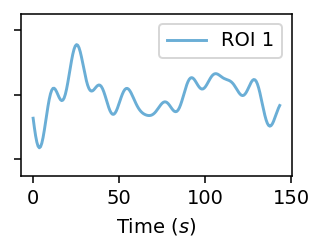

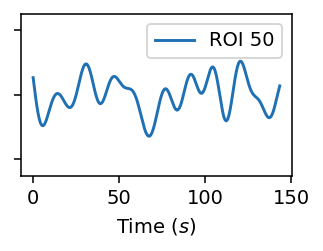

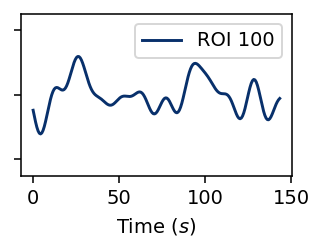

In [6]:
# Colormap for ROIs

cmap = plt.cm.Blues
colors = cmap(np.linspace(0.5, 1, len(roi_indices)))

(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
for i, roi in enumerate(roi_indices):
    fig, ax = plt.subplots(figsize=(w, h))
    fig.patch.set_alpha(0.0)
    plt.plot(time, filtered[roi], label=f"ROI {roi+1}", alpha=1.0, color=colors[i])
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); #ax.set_yticks([])
    ax.set_ylim(-v_lim,v_lim)
    # ax.set_xticks([]); ax.set_xticklabels([])
    ax.set_xlabel("Time ($s$)")
    plt.legend(loc="upper right")
    plt.savefig(project_root / "paper_new" / "images" / "representation" / f"filtered_timeseries_roi{roi}.svg", dpi=100, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"filtered_timeseries_roi{roi}.png", dpi=200, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"filtered_timeseries_roi{roi}.svg", bbox_inches="tight")

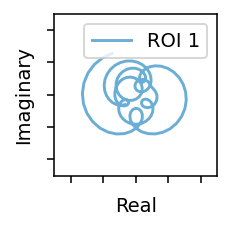

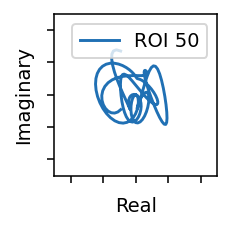

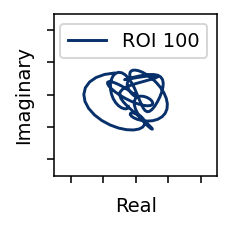

In [7]:

cmap = plt.cm.Blues
colors = cmap(np.linspace(0.5, 1, len(roi_indices)))

(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
for i, roi in enumerate(roi_indices):
    fig, ax = plt.subplots(figsize=(h, h))
    fig.patch.set_alpha(0.0)
    plt.plot(analytic[i].real, analytic[roi].imag, label=f"ROI {roi+1}", alpha=1.0, color=colors[i])
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); ax.set_xticklabels([])
    ax.set_xticks([-2, -1, 0, 1, 2]); ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_ylim(-v_lim, v_lim); ax.set_xlim(-v_lim, v_lim)
    ax.set_xlabel("Real"); ax.set_ylabel("Imaginary")

    ax.set_xticklabels([])
    plt.legend(loc="upper right")
    plt.savefig(project_root / "paper_new" / "images" / "representation" / f"analytic_timeseries_2d_roi{roi}.svg", dpi=100, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"analytic_timeseries_2d_roi{roi}.png", dpi=200, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"analytic_timeseries_2d_roi{roi}.svg", bbox_inches="tight")

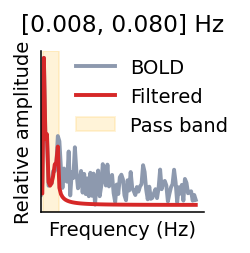

In [8]:
raw_spectrum = np.abs(np.fft.rfft(real[0]))
filtered_spectrum=np.abs(np.fft.rfft(filtered[0]))
frequencies=np.fft.rfftfreq(max_timepoints, d=dt)

fig, ax = plt.subplots(figsize=(h, h))
#fig.patch.set_alpha(0.0)
raw_spec = raw_spectrum / (raw_spectrum.max() + 1e-8)
filtered_spec = filtered_spectrum / (filtered_spectrum.max() + 1e-8)
ax.plot(frequencies, raw_spec, color="#8d99ae", linewidth=2.0, label="BOLD")
ax.plot(
    frequencies,
    filtered_spec,
    color="#d62828",
    linewidth=2.0,
    label="Filtered",
)
ax.axvspan(f_lo, f_hi, color="#ffd166", alpha=0.25, label="Pass band")
ax.set_title(f"[{f_lo:.3f}, {f_hi:.3f}] Hz", fontsize=12, pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Relative amplitude")
ax.set_yticks([]); ax.set_xticks([])
ax.set_xlim(left=0.0)
#ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=10, frameon=False, bbox_to_anchor=(1.2, 1.0), borderaxespad=0,)
plt.savefig(project_root / "paper_new" / "images" / "representation" / f"Band_pass.svg", dpi=100, bbox_inches="tight")
(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"Band_pass.png", dpi=200, bbox_inches="tight")
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"Band_pass.svg", bbox_inches="tight")

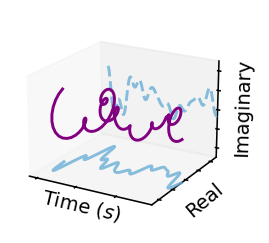

In [9]:
# Make a 3d plot of the analytic signal 
from mpl_toolkits.mplot3d.axes3d import Axes3D
id = 0
fig = plt.figure(figsize=(int(3*2), int(2)))
fig.patch.set_alpha(0.0)
ax = fig.add_subplot(111, projection='3d')
ax.plot(time, analytic[id].real, analytic[id].imag, linewidth=1.5, alpha=1.0, color="purple", linestyle='solid')
#ax.set_title(f"ROI {roi_indices[id]+1}", y=0.95)
ax.plot(time, v_lim, analytic[id].imag, alpha=0.8, color=colors[id], linestyle='--', label="Imag", zorder=0) # for setting the zlim
ax.plot(time, analytic[id].real, -v_lim, alpha=0.8, color=colors[id], linestyle='-', label="Real") # for setting the zlim
# Remove the grid and leave the horizontal lines only
ax.grid(False)   
ax.set_yticklabels([]); ax.set_zticklabels([])
ax.xaxis.set_tick_params(pad=-3)
ax.set_zticks([-2, -1, 0, 1, 2])
#ax.set_zticklabels(["-2i", "-i", "0", "i", "2i"])
ax.set_yticks([-2, -1, 0, 1, 2])
#ax.set_yticklabels(["-2", "-1", "0", "1", "2"])
ax.set_ylim(-v_lim, v_lim)
ax.set_zlim(-v_lim, v_lim)
ax.set_xlim(time[0]-10, time[-1])
ax.set_xticklabels([])
ax.set_xlabel("Time ($s$)", labelpad=-15)
ax.set_ylabel("Real", labelpad=-12, rotation=40)
ax.set_zlabel("Imaginary", rotation=90, labelpad=-13)
ax.view_init(elev=20, azim=-60)
#ax.set_yticklabels([])
#ax.set_zticklabels([])
# x_scale=1
# y_scale=1
# z_scale=1

# scale=np.diag([x_scale, y_scale, z_scale, 1.0])
# scale=scale*(1.0/scale.max())
# scale[3,3]=1.0

# def short_proj():
#   return np.dot(Axes3D.get_proj(ax), scale)

# ax.get_proj=short_proj

# for z_val in [-2, -1, 0, 1, 2]:
#     ax.plot([time[0], time[-1]], [v_lim, v_lim], [z_val, z_val],
#             color='k', alpha=0.4, linewidth=.5, zorder=0)
#     ax.plot([time[0], time[-1]], [z_val, z_val], [-v_lim,-v_lim],
#             color='k', alpha=0.4, linewidth=.5, zorder=0)
    


#plt.legend(loc="upper right")
plt.savefig(project_root / "paper_new" / "images" / "representation" / f"analytic_signal.svg", dpi=100, bbox_inches="tight")
(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"analytic_signal.png", dpi=200, bbox_inches="tight")
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"analytic_signal.svg", bbox_inches="tight")

# 2. Metrics

In [10]:
col, row = 33, 68

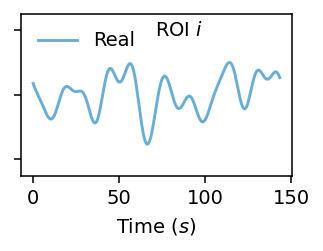

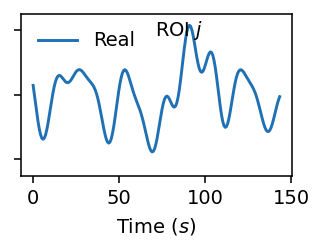

In [11]:
cmap = plt.cm.Blues
colors = cmap(np.linspace(0.5, 1, len(roi_indices)))

(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
for i, roi in enumerate([col, row]):
    fig, ax = plt.subplots(figsize=(w, h))
    fig.patch.set_alpha(0.0)
    plt.plot(time, filtered[roi], label=f"Real", color=colors[i])
    ax.text(time[-1]//2, v_lim-0.5, f"ROI {['$i$', '$j$'][i]}", va='center', fontsize=10)
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); #ax.set_yticks([])
    ax.set_ylim(-v_lim,v_lim)
    # ax.set_xticks([]); ax.set_xticklabels([])
    ax.set_xlabel("Time ($s$)")
    plt.legend(loc="upper left", framealpha=1, facecolor="white", frameon=True, edgecolor="white")
    plt.savefig(project_root / "paper_new" / "images" / "representation" / f"FC_timeseries_roi{['i','j'][i]}.svg", dpi=100, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"FC_timeseries_roi{['i','j'][i]}.png", dpi=200, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"FC_timeseries_roi{['i','j'][i]}.svg", bbox_inches="tight")

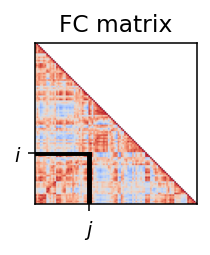

In [12]:
fc_data = compute_static_fc(torch.tensor(analytic))[0]
fig, ax = plt.subplots(figsize=(h, h))

n = len(fc_data)
mask = np.triu(np.ones((n, n), dtype=bool), k=1)  # Mask upper triangle
masked = np.where(mask, np.nan, fc_data)
ax.imshow(masked, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks([col]); ax.set_xticklabels(['$j$'])
ax.set_yticks([row]); ax.set_yticklabels(['$i$']) 

# Highlight a specific column and row with bounding boxes
box_kw = dict(linewidth=1.5, edgecolor="k", facecolor="none")
ax.set_title("FC matrix")

# Highlight column (only lower triangle cells)
ax.add_patch(patches.Rectangle((0 - 0.5, row - 0.5), col+1, 1, **box_kw))
ax.add_patch(patches.Rectangle((col - 0.5, 100 - 0.5), 1, row-100, **box_kw))

plt.savefig(project_root / "paper_new" / "images" / "representation" / f"FC_matrix.svg", dpi=200, bbox_inches="tight")
(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"FC_matrix.png", dpi=200, bbox_inches="tight")
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"FC_matrix.svg", bbox_inches="tight")

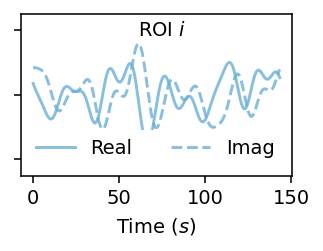

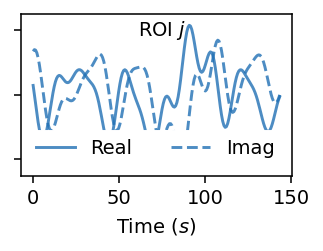

In [13]:
cmap1 = plt.cm.Blues
colors1 = cmap1(np.linspace(0.5, 1, len(roi_indices)))

(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
for i, roi in enumerate([col, row]):
    fig, ax = plt.subplots(figsize=(w, h))
    fig.patch.set_alpha(0.0)
    ax.plot(time, analytic[roi].real, label=f"Real", alpha=0.8, color=colors1[i])
    ax.plot(time, analytic[roi].imag, label=f"Imag", alpha=0.8, color=colors1[i], linestyle='--')
    ax.text(time[-1]//2-10, v_lim-0.5, f"ROI {['$i$', '$j$'][i]}", va='center', fontsize=10)
    # ax.set_title(f"ROI {['$i$', '$j$'][i]}", y=0.95)
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); #ax.set_yticks([])
    ax.set_ylim(-v_lim,v_lim)
    # ax.set_xticks([]); ax.set_xticklabels([])
    ax.set_xlabel("Time ($s$)")
    plt.legend(loc="lower right", framealpha=1, frameon=True, edgecolor="white", ncols=2)
    plt.savefig(project_root / "paper_new" / "images" / "representation" / f"phfc_timeseries_roi{['i','j'][i]}.svg", dpi=100, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"phfc_timeseries_roi{['i','j'][i]}.png", dpi=200, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"phfc_timeseries_roi{['i','j'][i]}.svg", bbox_inches="tight")

0.201037875659389


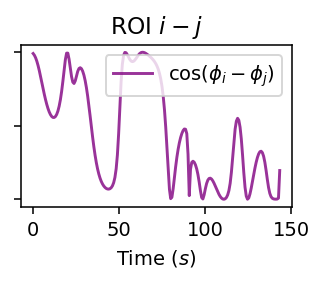

In [14]:
cmap1 = plt.cm.RdPu
colors1 = cmap1(np.linspace(0.5, 1, len(roi_indices)))

fig, ax = plt.subplots(figsize=(w, h))
phases = np.angle(analytic)
diff = np.expand_dims(phases, axis=0) - np.expand_dims(phases, axis=1)
diff = np.cos(diff)
ax.plot(time,diff[col, row], alpha=0.8, label="$\\cos(\\phi_i - \\phi_j)$", color="purple")
ax.set_title("ROI $i-j$")
ax.set_yticklabels([]); #ax.set_yticks([])
# ax.set_xticks([]); ax.set_xticklabels([])
ax.set_xlabel("Time ($s$)")
plt.legend(loc="upper right", )
phFC = diff.mean(axis=-2)
print(phFC[col, row])
# ax.axhline(y=phFC[col, row], color='red', linestyle='--', linewidth=1.5)
# ax.text(x=0.01, y=phFC[col, row] + 0.03, s=f'y = {phFC[col, row]:0.2f}', color='red', transform=ax.get_yaxis_transform())
plt.savefig(project_root / "paper_new" / "images" / "representation" / f"phases_coherence.svg", dpi=100, bbox_inches="tight")
(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"phases_coherence.png", dpi=200, bbox_inches="tight")
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"phases_coherence.svg", bbox_inches="tight")

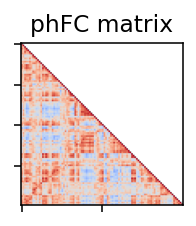

In [15]:
fc_data = diff.mean(axis=2)
fig, ax = plt.subplots(figsize=(h, h))

n = len(fc_data)
mask = np.triu(np.ones((n, n), dtype=bool), k=1)  # Mask upper triangle
masked = np.where(mask, np.nan, fc_data)
ax.imshow(masked, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticklabels([])
ax.set_yticklabels([]) 

# Highlight a specific column and row with bounding boxes
box_kw = dict(linewidth=1.5, edgecolor="k", facecolor="none")
ax.set_title("phFC matrix")

plt.savefig(project_root / "paper_new" / "images" / "representation" / f"phFC_matrix_analytic.svg", dpi=200, bbox_inches="tight")
(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"phFC_matrix_analytic.png", dpi=200, bbox_inches="tight")
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"phFC_matrix_analytic.svg", bbox_inches="tight")

# 3. Model

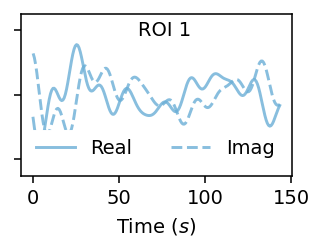

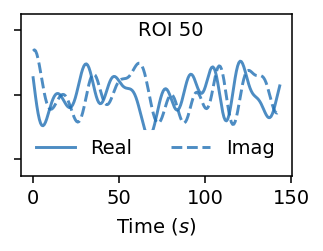

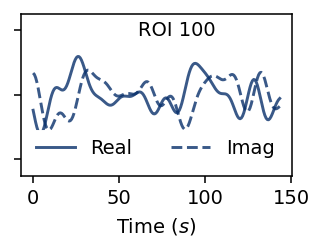

In [16]:
# Colormap for ROIs

cmap1 = plt.cm.Blues
colors1 = cmap1(np.linspace(0.5, 1, len(roi_indices)))

(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
for i, roi in enumerate(roi_indices):
    fig, ax = plt.subplots(figsize=(w, h))
    fig.patch.set_alpha(0.0)
    ax.plot(time, analytic[roi].real, label=f"Real", alpha=0.8, color=colors1[i])
    ax.plot(time, analytic[roi].imag, label=f"Imag", alpha=0.8, color=colors1[i], linestyle='--')
    ax.text(time[-1]//2 -10, v_lim-0.5, f"ROI {roi+1}", va='center', fontsize=10)
    # ax.set_title(f"ROI {roi+1}", y=0.97)
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); #ax.set_yticks([])
    ax.set_ylim(-v_lim,v_lim)
    # ax.set_xticks([]); ax.set_xticklabels([])
    ax.set_xlabel("Time ($s$)")
    plt.legend(loc="lower right", framealpha=1, frameon=True, edgecolor="white", ncols=2)
    plt.savefig(project_root / "paper_new" / "images" / "representation" / f"analytic_timeseries_roi{roi}.svg", dpi=100, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"analytic_timeseries_roi{roi}.png", dpi=200, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"analytic_timeseries_roi{roi}.svg", bbox_inches="tight")

In [17]:
model = CoupledHopfModel(
    n_rois=100,
    initial_a=-0.02,   # Bifurcation parameter (near criticality)
    initial_g=1.0,      # Global coupling strength
    initial_kappa=0.1,  # Scaling factor for local dynamics
    noise_sigma=0.1,    # Noise amplitude (default)
)
with torch.no_grad():
    timeseries = model.forward(initial_state=torch.tensor(analytic[None, :, 0]), n_steps=max_timepoints)  # (10, 68, 300) complex
    fc_matrix = model.compute_fc(timeseries)
timeseries = timeseries.detach().numpy()

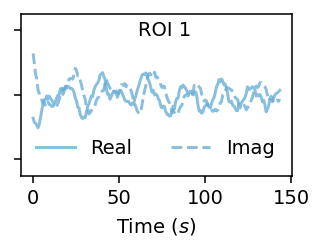

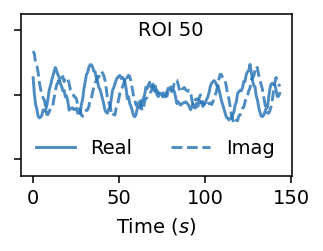

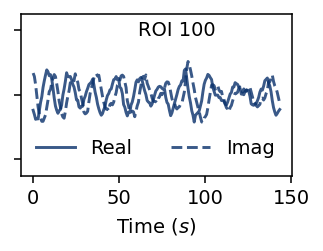

In [18]:
# Colormap for ROIs
cmap1 = plt.cm.Blues
colors1 = cmap1(np.linspace(0.5, 1, len(roi_indices)))
cmap2 = plt.cm.Reds
colors2 = cmap2(np.linspace(0.5, 1, len(roi_indices)))

(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
for i, roi in enumerate(roi_indices):
    fig, ax = plt.subplots(figsize=(w, h))
    fig.patch.set_alpha(0.0)
    ax.plot(time, timeseries[0, roi].real, label=f"Real", alpha=0.8, color=colors1[i])
    ax.plot(time, timeseries[0, roi].imag, label=f"Imag", alpha=0.8, color=colors1[i], linestyle='--')
    ax.text(time[-1]//2 -10, v_lim-0.5, f"ROI {roi+1}", va='center', fontsize=10)
    # ax.set_title(f"ROI {roi+1}", y=0.97)
    #ax.set_title(f"Subject {pipeline.subject_index}, ROI {roi}")
    ax.set_yticklabels([]); #ax.set_yticks([])
    ax.set_ylim(-v_lim,v_lim)
    # ax.set_xticks([]); ax.set_xticklabels([])
    ax.set_xlabel("Time ($s$)")
    plt.legend(loc="lower right", framealpha=1, frameon=True, edgecolor="white", ncols=2)
    plt.savefig(project_root / "paper_new" / "images" / "representation" / f"model_timeseries_roi{roi}.svg", dpi=100, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"model_timeseries_roi{roi}.png", dpi=200, bbox_inches="tight")
    plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"model_timeseries_roi{roi}.svg", bbox_inches="tight")

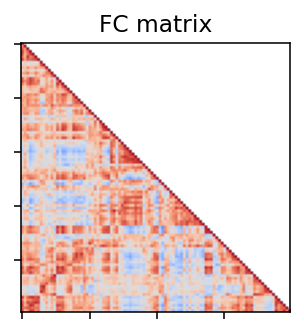

In [19]:
fc_data = compute_static_fc(torch.tensor(analytic))[0]
fig, ax = plt.subplots(figsize=(w, w))
fig.patch.set_alpha(0.0)

n = len(fc_data)
mask = np.triu(np.ones((n, n), dtype=bool), k=1)  # Mask upper triangle
masked = np.where(mask, np.nan, fc_data)
ax.imshow(masked, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticklabels([])
ax.set_yticklabels([]) 

# Highlight a specific column and row with bounding boxes
box_kw = dict(linewidth=1.5, edgecolor="k", facecolor="none")
ax.set_title("FC matrix")


plt.savefig(project_root / "paper_new" / "images" / "representation" / f"FC_matrix_analytic.svg", dpi=100, bbox_inches="tight")
(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"FC_matrix_analytic.png", dpi=200, bbox_inches="tight")
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"FC_matrix_analytic.svg", bbox_inches="tight")

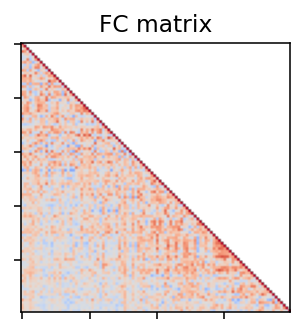

In [20]:
fc_data = compute_static_fc(torch.tensor(timeseries))[0]
fig, ax = plt.subplots(figsize=(w, w))
fig.patch.set_alpha(0.0)

n = len(fc_data)
mask = np.triu(np.ones((n, n), dtype=bool), k=1)  # Mask upper triangle
masked = np.where(mask, np.nan, fc_data)
ax.imshow(masked, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticklabels([])
ax.set_yticklabels([]) 

# Highlight a specific column and row with bounding boxes
box_kw = dict(linewidth=1.5, edgecolor="k", facecolor="none")
ax.set_title("FC matrix")

plt.savefig(project_root / "paper_new" / "images" / "representation" / f"FC_matrix_model.svg", dpi=100, bbox_inches="tight")
(project_root / "paper_new" / "images_png" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_png" / "representation" / f"FC_matrix_model.png", dpi=200, bbox_inches="tight")
(project_root / "paper_new" / "images_svg" / "representation").mkdir(parents=True, exist_ok=True)
plt.savefig(project_root / "paper_new" / "images_svg" / "representation" / f"FC_matrix_model.svg", bbox_inches="tight")